# ReSIM: Re-ranking Binary Similarity Embeddings to Improve Function Search Performance

## Reproducibility Notebook

This notebook reproduces the experimental results from the paper.

In [5]:
import os

from metrics import *
from utils import *

BASE_PATH = "/app/vol/reSAFE_code"

# Dataset configurations
DATASETS = {
    "bincorp": {
        "pool_size": 5000,
        "n_queries": 5000,
        "n_pool_functions": 25000,
        "search_depth": 200,
    },
    "multicomp": {
        "pool_size": 1000,
        "n_queries": 1000, 
        "n_pool_functions": 11622,
        "search_depth": 200,
    },
}

# Models evaluated
BFS_MODELS = ["GEMINI", "SAFE", "JTRANS", "CLAP", "BINBERT", "PALMTREE", "TREX"]
RERANKER_NAME = "reDEEP"

# k values for tables
K_VALUES = [5, 10, 15, 20, 25, 30]
K_INDICES = [k - 1 for k in K_VALUES]


SAVE_FIGURES = True
FIGURE_OUTPUT_DIR = os.path.join(BASE_PATH, "function_search", 
                                  "search_results", "PAPER_FIGURES")
os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
# RQ1: Performance of ReSIM Across Various Compilation Toolchains

In [15]:
print("=" * 80)
print("RQ1: Performance of ReSIM Across Various Compilation Toolchains")
print("=" * 80)

results_bincorp = load_rq1_data("bincorp")
df_rq1_bincorp = generate_rq1_table("bincorp", results_bincorp)

print()

results_multicomp = load_rq1_data("multicomp")
df_rq1_multicomp = generate_rq1_table("multicomp", results_multicomp)


# Generate improvement table
if results_bincorp and results_multicomp:
    df_improvements = generate_improvement_table(results_bincorp, results_multicomp)

RQ1: Performance of ReSIM Across Various Compilation Toolchains

Table 1: nDCG and Recall for BINCORP (w=200)


,Dataset,BFS Model,Reranker,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@15,Recall@15,nDCG@20,Recall@20,nDCG@25,Recall@25,nDCG@30,Recall@30
0,BINCORP,GEMINI,✗,0.40,0.27,0.41,0.30,0.42,0.31,0.42,0.32,0.43,0.33,0.43,0.34
1,,,✓,0.57,0.45,0.57,0.45,0.57,0.46,0.57,0.46,0.57,0.46,0.57,0.46
2,,SAFE,✗,0.54,0.42,0.57,0.48,0.58,0.51,0.59,0.53,0.60,0.55,0.61,0.57
3,,,✓,0.77,0.69,0.78,0.71,0.78,0.71,0.78,0.71,0.78,0.72,0.78,0.72
4,,JTRANS,✗,0.75,0.68,0.80,0.77,0.82,0.81,0.83,0.83,0.84,0.85,0.84,0.86
5,,,✓,0.91,0.88,0.94,0.93,0.95,0.94,0.95,0.95,0.95,0.95,0.95,0.95
6,,CLAP,✗,0.87,0.83,0.89,0.87,0.90,0.89,0.91,0.90,0.91,0.91,0.91,0.91
7,,,✓,0.91,0.88,0.94,0.92,0.94,0.94,0.94,0.94,0.94,0.94,0.94,0.95
8,,BINBERT,✗,0.74,0.66,0.78,0.73,0.79,0.76,0.80,0.78,0.80,0.79,0.81,0.80
9,,,✓,0.88,0.84,0.90,0.87,0.90,0.88,0.91,0.88,0.91,0.88,0.91,0.89




Table 1: nDCG and Recall for MULTICOMP (w=200)


,Dataset,BFS Model,Reranker,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@15,Recall@15,nDCG@20,Recall@20,nDCG@25,Recall@25,nDCG@30,Recall@30
0,MULTICOMP,GEMINI,✗,0.61,0.25,0.49,0.31,0.46,0.34,0.46,0.36,0.47,0.38,0.48,0.40
1,,,✓,0.84,0.39,0.71,0.51,0.67,0.54,0.66,0.55,0.66,0.56,0.66,0.56
2,,SAFE,✗,0.74,0.33,0.62,0.43,0.60,0.49,0.61,0.53,0.62,0.56,0.63,0.58
3,,,✓,0.92,0.45,0.85,0.66,0.82,0.72,0.81,0.74,0.81,0.75,0.81,0.76
4,,JTRANS,✗,0.74,0.32,0.63,0.43,0.60,0.48,0.60,0.50,0.61,0.53,0.61,0.54
5,,,✓,0.90,0.43,0.80,0.59,0.77,0.65,0.76,0.67,0.76,0.68,0.76,0.69
6,,CLAP,✗,0.88,0.42,0.81,0.62,0.79,0.70,0.80,0.74,0.80,0.77,0.81,0.78
7,,,✓,0.92,0.45,0.86,0.67,0.84,0.76,0.84,0.80,0.85,0.82,0.85,0.83
8,,BINBERT,✗,0.91,0.45,0.86,0.67,0.84,0.76,0.84,0.80,0.85,0.83,0.86,0.84
9,,,✓,0.94,0.47,0.91,0.72,0.90,0.82,0.90,0.87,0.90,0.88,0.91,0.89



Table 2: Improvement (%) after applying reDEEP reranker


,Dataset,BFS Model,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30,nDCG AVG,Recall AVG
0,BINCORP,GEMINI,+42.5%,+66.7%,+39.0%,+50.0%,+35.7%,+43.8%,+32.6%,+35.3%,+37.4%,+48.9%
1,,SAFE,+42.6%,+64.3%,+36.8%,+47.9%,+32.2%,+34.0%,+27.9%,+26.3%,+34.9%,+43.1%
2,,JTRANS,+21.3%,+29.4%,+17.5%,+20.8%,+14.5%,+14.5%,+13.1%,+10.5%,+16.6%,+18.8%
3,,CLAP,+4.6%,+6.0%,+5.6%,+5.7%,+3.3%,+4.4%,+3.3%,+4.4%,+4.2%,+5.2%
4,,BINBERT,+18.9%,+27.3%,+15.4%,+19.2%,+13.7%,+12.8%,+12.3%,+11.2%,+15.1%,+17.6%
5,,PALMTREE,+28.8%,+41.7%,+24.6%,+32.7%,+22.2%,+25.0%,+20.3%,+20.7%,+24.0%,+30.0%
6,,TREX,+32.8%,+48.0%,+26.2%,+35.7%,+22.4%,+24.2%,+20.6%,+18.5%,+25.5%,+31.6%
7,MULTICOMP,GEMINI,+37.7%,+56.0%,+44.9%,+64.5%,+43.5%,+52.8%,+37.5%,+40.0%,+40.9%,+53.3%
8,,SAFE,+24.3%,+36.4%,+37.1%,+53.5%,+32.8%,+39.6%,+28.6%,+31.0%,+30.7%,+40.1%
9,,JTRANS,+21.6%,+34.4%,+27.0%,+37.2%,+26.7%,+34.0%,+24.6%,+27.8%,+25.0%,+33.3%



--- BinCorp Figures ---
Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ1_ndcg_bincorp.pdf


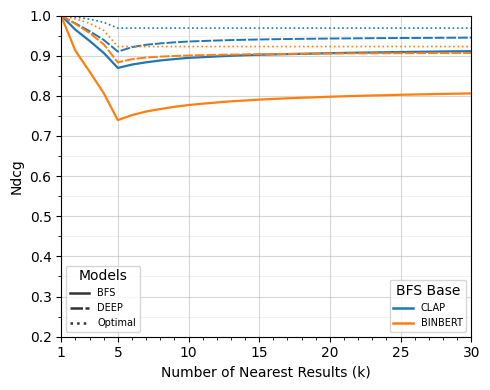

Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ1_recall_bincorp.pdf


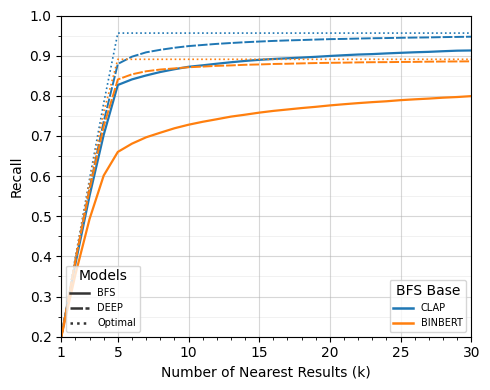


--- MultiComp Figures ---
Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ1_ndcg_multicomp.pdf


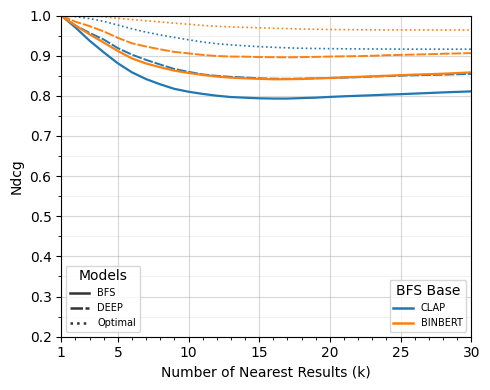

Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ1_recall_multicomp.pdf


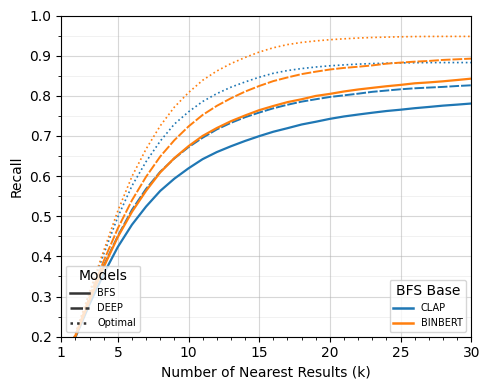

In [16]:
# Generate RQ1 figures
if results_bincorp:
    print("\n--- BinCorp Figures ---")
    for metric in ["ndcg", "recall"]:
        save_path = os.path.join(FIGURE_OUTPUT_DIR, 
                                 f"RQ1_{metric}_bincorp.pdf") if SAVE_FIGURES else None
        plot_rq1_curves("bincorp", results_bincorp, 
                       models_to_plot=["CLAP", "BINBERT"], 
                       metric=metric, save_path=save_path)

if results_multicomp:
    print("\n--- MultiComp Figures ---")
    for metric in ["ndcg", "recall"]:
        save_path = os.path.join(FIGURE_OUTPUT_DIR, 
                                 f"RQ1_{metric}_multicomp.pdf") if SAVE_FIGURES else None
        plot_rq1_curves("multicomp", results_multicomp, 
                       models_to_plot=["CLAP", "BINBERT"], 
                       metric=metric, save_path=save_path)

---
# RQ2: Impact of the Window Size $w$

RQ2: Impact of Window Size

--- Dataset: BINCORP ---

RQ2: Window Size Comparison for JTRANS on BINCORP


,Window,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30
0,baseline,0.75,0.68,0.80,0.77,0.83,0.83,0.84,0.86
1,w=30,0.88,0.84,0.89,0.86,0.90,0.86,0.90,0.86
2,w=50,0.90,0.86,0.91,0.89,0.92,0.89,0.92,0.90
3,w=100,0.91,0.88,0.93,0.92,0.94,0.93,0.94,0.93
4,w=200,0.91,0.88,0.94,0.93,0.95,0.95,0.95,0.95


Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ2_JTRANS_recall_bincorp_window_compare.pdf


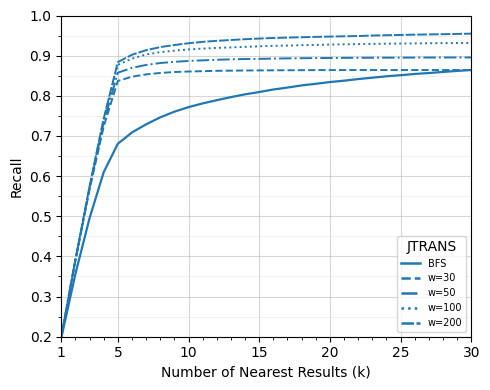


RQ2: Window Size Comparison for CLAP on BINCORP


,Window,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30
0,baseline,0.87,0.83,0.89,0.87,0.91,0.90,0.91,0.91
1,w=30,0.91,0.88,0.93,0.91,0.93,0.91,0.93,0.91
2,w=50,0.91,0.88,0.93,0.91,0.94,0.92,0.94,0.93
3,w=100,0.91,0.88,0.93,0.92,0.94,0.93,0.94,0.94
4,w=200,0.91,0.88,0.94,0.92,0.94,0.94,0.94,0.95


Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ2_CLAP_recall_bincorp_window_compare.pdf


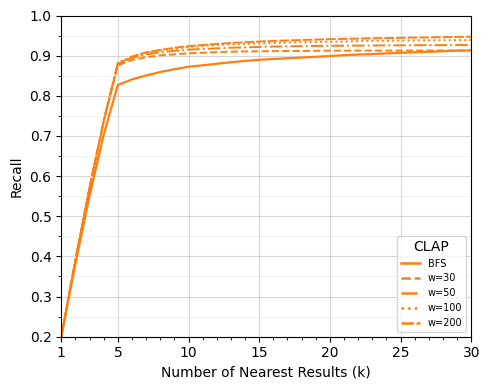


RQ2: Window Size Comparison for BINBERT on BINCORP


,Window,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30
0,baseline,0.74,0.66,0.78,0.73,0.80,0.78,0.81,0.80
1,w=30,0.84,0.78,0.85,0.80,0.85,0.80,0.85,0.80
2,w=50,0.85,0.80,0.86,0.82,0.87,0.82,0.87,0.83
3,w=100,0.87,0.82,0.88,0.85,0.89,0.86,0.89,0.86
4,w=200,0.88,0.84,0.90,0.87,0.91,0.88,0.91,0.89


Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ2_BINBERT_recall_bincorp_window_compare.pdf


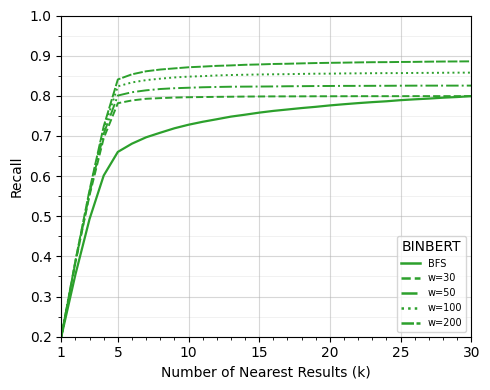


--- Dataset: MULTICOMP ---

RQ2: Window Size Comparison for JTRANS on MULTICOMP


,Window,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30
0,baseline,0.74,0.32,0.63,0.43,0.60,0.50,0.61,0.54
1,w=30,0.84,0.39,0.72,0.50,0.66,0.54,0.65,0.54
2,w=50,0.86,0.40,0.74,0.53,0.69,0.58,0.68,0.58
3,w=100,0.88,0.41,0.77,0.56,0.73,0.63,0.73,0.64
4,w=200,0.90,0.43,0.80,0.59,0.76,0.67,0.76,0.69


Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ2_JTRANS_recall_multicomp_window_compare.pdf


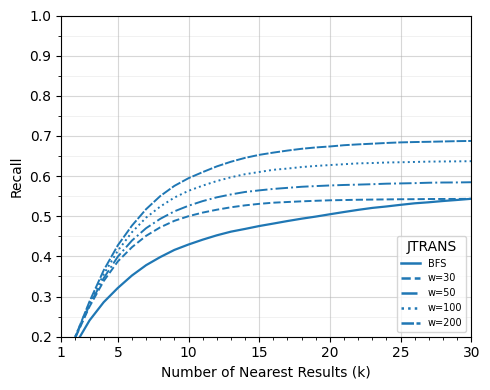


RQ2: Window Size Comparison for CLAP on MULTICOMP


,Window,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30
0,baseline,0.88,0.42,0.81,0.62,0.80,0.74,0.81,0.78
1,w=30,0.92,0.45,0.85,0.66,0.82,0.76,0.83,0.78
2,w=50,0.92,0.45,0.86,0.67,0.84,0.78,0.84,0.80
3,w=100,0.92,0.45,0.86,0.67,0.84,0.79,0.85,0.82
4,w=200,0.92,0.45,0.86,0.67,0.84,0.80,0.85,0.83


Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ2_CLAP_recall_multicomp_window_compare.pdf


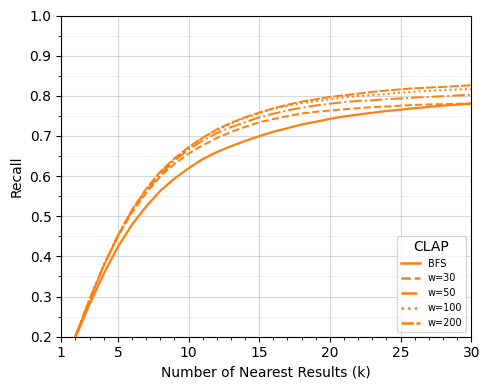


RQ2: Window Size Comparison for BINBERT on MULTICOMP


,Window,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@20,Recall@20,nDCG@30,Recall@30
0,baseline,0.91,0.45,0.86,0.67,0.84,0.80,0.86,0.84
1,w=30,0.95,0.47,0.90,0.72,0.88,0.83,0.88,0.84
2,w=50,0.95,0.47,0.91,0.73,0.89,0.85,0.89,0.87
3,w=100,0.95,0.47,0.91,0.73,0.90,0.86,0.91,0.89
4,w=200,0.94,0.47,0.91,0.72,0.90,0.87,0.91,0.89


Saved: /app/vol/reSAFE_code/function_search/search_results/PAPER_FIGURES/RQ2_BINBERT_recall_multicomp_window_compare.pdf


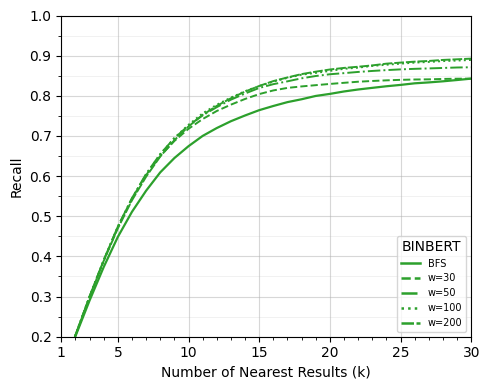

In [17]:
print("=" * 80)
print("RQ2: Impact of Window Size")
print("=" * 80)

top_models = ["JTRANS", "CLAP", "BINBERT"]
window_sizes = [30, 50, 100, 200]

for db_name in ["bincorp", "multicomp"]:
    display_name = "BINCORP" if db_name == "bincorp" else "MULTICOMP"
    print(f"\n--- Dataset: {display_name} ---")
    
    for model in top_models:
        try:
            rq2_results = load_rq2_data(db_name, model, window_sizes)
            generate_rq2_table(db_name, model, rq2_results)
            
            if SAVE_FIGURES:
                save_path = os.path.join(
                    FIGURE_OUTPUT_DIR, 
                    f"RQ2_{model}_recall_{db_name}_window_compare.pdf"
                )
            else:
                save_path = None
                
            plot_window_comparison(
                rq2_results, model, db_name, 
                metric="recall", save_path=save_path
            )
        except Exception as e:
            print(f"  Error processing {model}: {e}")

---
# RQ3: Ensembling Embedding Models with ReSIM

In [18]:
print("=" * 80)
print("RQ3: Ensembling Embedding Models")
print("=" * 80)

df_rq3 = generate_rq3_table()

RQ3: Ensembling Embedding Models

Table 3: Ensemble Results (jTrans + BinBERT, top-100 merged)


,BFS Model,Reranker,nDCG@5,Recall@5,nDCG@10,Recall@10,nDCG@15,Recall@15,nDCG@20,Recall@20,nDCG@25,Recall@25,nDCG@30,Recall@30
0,ENSEMBLE (jTrans+BinBERT),✓,0.92,0.89,0.95,0.94,0.95,0.95,0.96,0.96,0.96,0.97,0.96,0.97


---
# RQ4: Impact of Pre-Training

In [ ]:
df_rq4 = display_rq4_results()

# Optionally load actual data if checkpoints are available
# rq4_results = load_rq4_data("bincorp", "CLAP")